In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import drive
import statsmodels.api as sm
import numpy as np


In [ ]:
file_path = "/content/drive/MyDrive/Analisis matemático/FINALMODELOajustelocal.csv"
df_modelo = pd.read_csv(file_path, encoding='latin1')

In [ ]:
df_modelo["LOG_POBLACION_TOTAL"] = np.log(df_modelo["POBLACION_TOTAL"].replace(0, np.nan))
df_modelo["LOG_POBLACION_20_24"] = np.log(df_modelo["POBLACION_20_24"].replace(0, np.nan))


In [ ]:
df_modelo

,COUNTRY,YEAR,POBLACION_0_14,POBLACION_TOTAL,PIB_POR_PAIS,TASA_MORTALIDAD_INFANTIL,POBLACION_20_24_VARONES,POBLACION_20_24_MUJERES,MEDALLAS_TOTALES_POR_PAIS_POR_AÑO,MEDALLAS_DE_ORO_TOTALES_POR_PAIS_POR_AÑO,...,MEDALLAS_PREDICHAS,ERROR_ABSOLUTO_MEDALLAS,BOICOT_1980,BOICOT_1984,DUMMY_AUSTRALIA,DUMMY_UK,DUMMY_CHINA_MODERNA,DUMMY_FRANCE,LOG_POBLACION_TOTAL,LOG_POBLACION_20_24
0,Afghanistan,2008,13043065,26482622.0,381.733238,69.6,8.50,8.33,1,0,...,2.871497,1.871497,0,0,0,0,0,0,17.091999,15.309992
1,Afghanistan,2012,14548198,30560034.0,651.417134,60.1,9.06,8.89,1,0,...,2.942766,1.942766,0,0,0,0,0,0,17.235204,15.517624
2,Albania,2024,467968,2745972.0,8575.171134,8.4,7.40,6.80,2,0,...,6.640047,4.640047,0,0,0,0,0,0,14.825646,12.873717
3,Algeria,1984,9580584,21271969.0,2524.380714,67.7,9.51,9.02,2,0,...,3.328880,1.328881,0,1,0,0,0,0,16.872901,15.187122
4,Algeria,1992,10910578,26628568.0,1802.693008,42.1,9.95,9.53,2,1,...,4.585902,2.585902,0,0,0,0,0,0,17.097495,15.461713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1054,Zambia,1996,4343670,9004053.0,399.511305,100.3,9.72,9.46,1,0,...,2.032876,1.032876,0,0,0,0,0,0,16.013185,14.361883
1055,Zambia,2024,8694765,20723965.0,1330.727806,40.9,9.41,9.37,1,0,...,4.056975,3.056975,0,0,0,0,0,0,16.846801,15.174424
1056,Zimbabwe,1980,3428620,7041303.0,948.527311,70.5,7.87,9.40,15,15,...,3.164395,11.835605,1,0,0,0,0,0,15.767304,14.011105
1057,Zimbabwe,2004,5154172,12365896.0,469.484654,51.6,11.68,12.62,3,1,...,3.655562,0.655562,0,0,0,0,0,0,16.330453,14.915759


In [ ]:
# 1. Crear nuevos dummies

# China moderna (año >= 2000)
df_modelo["DUMMY_CHINA_MODERNA"] = df_modelo.apply(lambda row: 1 if row["COUNTRY"] == "China" and row["YEAR"] >= 2008 else 0, axis=1)
df_modelo["DUMMY_KOREA_MODERNA"] = df_modelo.apply(lambda row: 1 if row["COUNTRY"] == "South Korea" and row["YEAR"] >= 1988 else 0, axis=1)

# Francia (en general)
df_modelo["DUMMY_FRANCE"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "France" else 0)
df_modelo["DUMMY_ITALY"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Italy" else 0)
df_modelo["DUMMY_HUNGARY"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Hungary" else 0)
df_modelo["DUMMY_JAPAN"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Japan" else 0)
df_modelo["DUMMY_BULGARIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Bulgaria" else 0)
df_modelo["DUMMY_CUBA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Cuba" else 0)
df_modelo["DUMMY_NETHERLANDS"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Netherlands" else 0)
df_modelo["DUMMY_NETHERLANDS"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Netherlands" else 0)
df_modelo["DUMMY_ROMANIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Romania" else 0)
df_modelo["DUMMY_SPAIN"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Spain" else 0)
df_modelo["DUMMY_SERBIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Serbia" else 0)
df_modelo["DUMMY_CANADA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Canada" else 0)
df_modelo["DUMMY_BRAZIL"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Brazil" else 0)
df_modelo["DUMMY_POLAND"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Poland" else 0)
# 2. Redefinir X con las nuevas variables
X = df_modelo[[
    "LOG_PIB_REAL",
    #"LOG_POBLACION_TOTAL",
    "LOG_POBLACION_20_24",
    "TASA_MORTALIDAD_INFANTIL_CENTRADO",
    "LOCAL",
    #"VECINO",
   #"DUMMY_CHINA_MODERNA"
    "DUMMY_RUSSIA"
    #"DUMMY_USA"
   # "DUMMY_GERMANY",
  #  # "BOICOT_1980",
  #  # "BOICOT_1984",
  #   "DUMMY_AUSTRALIA",
  #   "DUMMY_UK",
  #   "DUMMY_FRANCE",
  #   "DUMMY_ITALY",
  #   "DUMMY_HUNGARY",
  #   "DUMMY_JAPAN",
  #   "DUMMY_BULGARIA",
  #   "DUMMY_CUBA",
   # "DUMMY_KOREA_MODERNA"
  #   "DUMMY_NETHERLANDS",
  #   "DUMMY_ROMANIA",
  #   "DUMMY_SPAIN",
  #  "DUMMY_SERBIA",
  #   "DUMMY_CANADA",
  #   "DUMMY_BRAZIL",
  #   "DUMMY_POLAND"

]]

# 3. Agregar constante
X = sm.add_constant(X)

# 4. Definir y
y= df_modelo["LOG_PROP_MEDALLAS"]

# 5. Ajustar el modelo
modelo = sm.OLS(y, X).fit()

# 6. Mostrar el resumen del modelo
print(modelo.summary())



                            OLS Regression Results                            
Dep. Variable:      LOG_PROP_MEDALLAS   R-squared:                       0.387
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     133.2
Date:                Thu, 01 May 2025   Prob (F-statistic):          1.88e-109
Time:                        23:16:52   Log-Likelihood:                -1726.2
No. Observations:                1059   AIC:                             3464.
Df Residuals:                    1053   BIC:                             3494.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [ ]:
import numpy as np

# 1. Predecir log(ŵ_it) con el modelo
log_predicciones = modelo.predict(X)

# 2. Destransformar: volver a escala real (ŵ_it)
predicciones = np.exp(log_predicciones)

# 3. Agregar las predicciones al dataframe de modelado
df_modelo["PROP_MEDALLAS_PREDICHA"] = predicciones

# 4. Opcional: calcular error absoluto entre proporción real y predicha
df_modelo["ERROR_ABSOLUTO"] = np.abs(df_modelo["PROP_MEDALLAS"] - df_modelo["PROP_MEDALLAS_PREDICHA"])

# 5. Mostrar ejemplo de tabla de resultados
resultados = df_modelo[[
    "COUNTRY",
    "YEAR",
    "MEDALLAS_TOTALES_POR_PAIS_POR_AÑO",
    "PROP_MEDALLAS",
    "PROP_MEDALLAS_PREDICHA",
    "ERROR_ABSOLUTO"
]].sort_values(by="ERROR_ABSOLUTO", ascending=False)

# Mostrar los 10 países con mayor error
resultados.head(10)


,COUNTRY,YEAR,MEDALLAS_TOTALES_POR_PAIS_POR_AÑO,PROP_MEDALLAS,PROP_MEDALLAS_PREDICHA,ERROR_ABSOLUTO
1019,United States,1984,352,0.238644,0.038584,0.200060
353,Germany,1972,253,0.208230,0.020532,0.187698
354,Germany,1976,273,0.206818,0.021341,0.185477
355,Germany,1980,264,0.190614,0.023620,0.166993
797,Russia,1980,442,0.319134,0.152294,0.166840
357,Germany,1988,296,0.187223,0.022272,0.164951
1025,United States,2008,317,0.155316,0.026596,0.128720
1015,United States,1964,169,0.164237,0.039108,0.125129
1016,United States,1968,166,0.157197,0.040110,0.117087
1029,United States,2024,321,0.141722,0.026125,0.115597


In [ ]:
# 1. Primero, recuperar el total de medallas entregadas cada año
total_medallas_por_ano = df_modelo.groupby("YEAR")["MEDALLAS_TOTALES_POR_PAIS_POR_AÑO"].transform("sum")

# 2. Calcular las medallas reales y predichas en números absolutos
df_modelo["MEDALLAS_REALES"] = df_modelo["PROP_MEDALLAS"] * total_medallas_por_ano
df_modelo["MEDALLAS_PREDICHAS"] = df_modelo["PROP_MEDALLAS_PREDICHA"] * total_medallas_por_ano

# 3. Calcular error absoluto en número de medallas
df_modelo["ERROR_ABSOLUTO_MEDALLAS"] = np.abs(df_modelo["MEDALLAS_REALES"] - df_modelo["MEDALLAS_PREDICHAS"])

# 4. Armar la tabla ordenada
tabla_resultados = df_modelo[[
    "COUNTRY",
    "YEAR",
    "MEDALLAS_REALES",
    "MEDALLAS_PREDICHAS",
    "ERROR_ABSOLUTO_MEDALLAS"
]].sort_values(by="ERROR_ABSOLUTO_MEDALLAS", ascending=False)

# 5. Mostrar los 10 países con mayor error absoluto
tabla_resultados.head(15)


,COUNTRY,YEAR,MEDALLAS_REALES,MEDALLAS_PREDICHAS,ERROR_ABSOLUTO_MEDALLAS
1019,United States,1984,352.000000,56.910777,295.089223
1025,United States,2008,317.000001,54.283321,262.716680
1029,United States,2024,320.999999,59.172143,261.827856
357,Germany,1988,295.999999,35.212750,260.787249
354,Germany,1976,273.000000,28.170077,244.829923
1028,United States,2020,298.000001,56.351122,241.648879
355,Germany,1980,263.999999,32.714371,231.285629
797,Russia,1980,442.000000,210.926807,231.073193
353,Germany,1972,253.000000,24.946532,228.053468
1027,United States,2016,264.000001,50.805786,213.194214


In [ ]:
tabla_resultados.to_excel("RESULTADOS6.xlsx", index=False)

In [ ]:
df=tabla_resultados

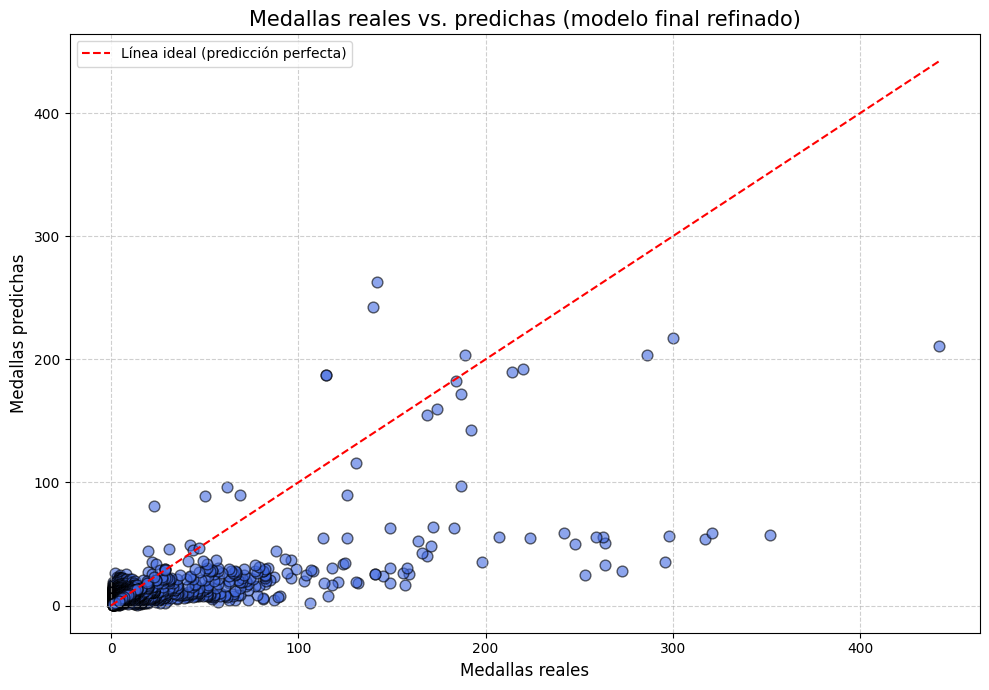

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar archivo de resultados
#df = pd.read_excel("RESULTADOS5.xlsx")  # Asegúrate de tener este archivo en tu carpeta de trabajo

# 2. Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# 3. Seleccionar las columnas necesarias y eliminar valores nulos
df_grafico = df[["COUNTRY", "YEAR", "MEDALLAS_REALES", "MEDALLAS_PREDICHAS"]].dropna()

# 4. Crear gráfico
plt.figure(figsize=(10, 7))
plt.scatter(
    df_grafico["MEDALLAS_REALES"],
    df_grafico["MEDALLAS_PREDICHAS"],
    alpha=0.6,
    color='royalblue',
    edgecolors='black',
    s=60,
    marker='o'
)
plt.plot(
    [0, df_grafico["MEDALLAS_REALES"].max()],
    [0, df_grafico["MEDALLAS_REALES"].max()],
    'r--',
    label='Línea ideal (predicción perfecta)'
)

# 5. Etiquetas y formato
plt.title("Medallas reales vs. predichas (modelo final refinado)", fontsize=15)
plt.xlabel("Medallas reales", fontsize=12)
plt.ylabel("Medallas predichas", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 6. Mostrar
plt.show()


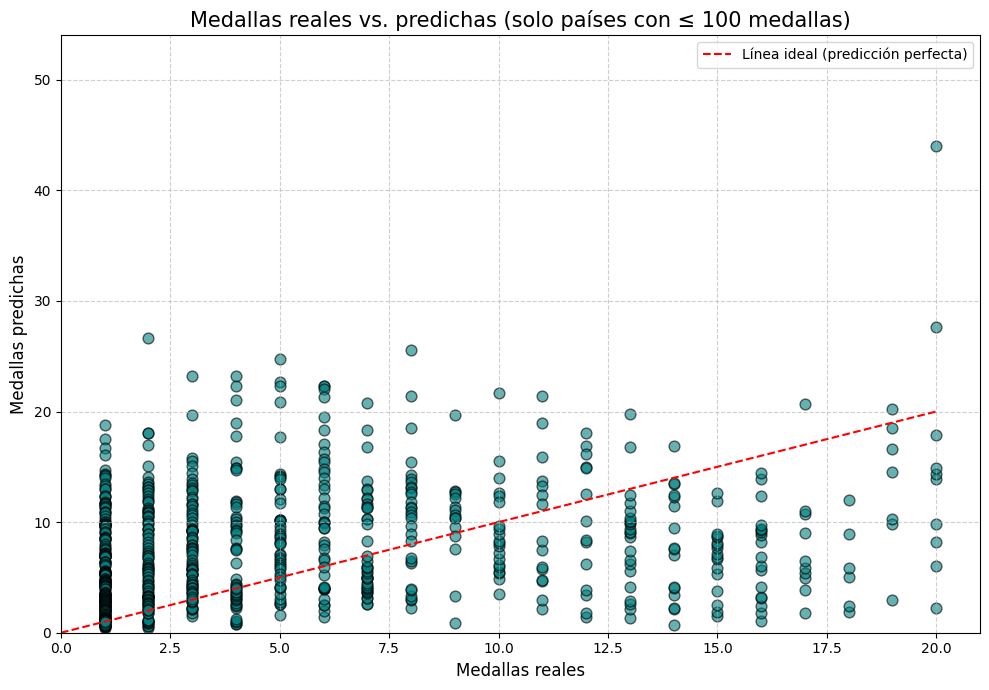

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar datos
df.columns = df.columns.str.strip()

# 2. Filtrar solo países con hasta 100 medallas reales
df_sub = df[df["MEDALLAS_REALES"] <= 20].dropna(subset=["MEDALLAS_REALES", "MEDALLAS_PREDICHAS"])

# 3. Crear gráfico
plt.figure(figsize=(10, 7))
plt.scatter(
    df_sub["MEDALLAS_REALES"],
    df_sub["MEDALLAS_PREDICHAS"],
    alpha=0.6,
    color='teal',
    edgecolors='black',
    s=60,
    marker='o'
)
plt.plot(
    [0, 20],
    [0, 20],
    'r--',
    label='Línea ideal (predicción perfecta)'
)

# 4. Etiquetas y formato
plt.title("Medallas reales vs. predichas (solo países con ≤ 100 medallas)", fontsize=15)
plt.xlabel("Medallas reales", fontsize=12)
plt.ylabel("Medallas predichas", fontsize=12)
plt.xlim(0, 21)
plt.ylim(0, df_sub["MEDALLAS_PREDICHAS"].max() + 10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 5. Mostrar
plt.show()


In [ ]:
import pandas as pd

# 1. Cargar archivo de resultados
df.columns = df.columns.str.strip()

# 2. Agrupar por país y sumar medallas reales y predichas
tabla_resumen = df.groupby("COUNTRY")[["MEDALLAS_REALES", "MEDALLAS_PREDICHAS"]].sum().reset_index()

# 3. Calcular el error absoluto total por país
tabla_resumen["ERROR_ABSOLUTO_TOTAL"] = abs(tabla_resumen["MEDALLAS_REALES"] - tabla_resumen["MEDALLAS_PREDICHAS"])

# 4. Renombrar columnas para claridad
tabla_resumen.columns = ["COUNTRY", "MEDALLAS_REALES_TOTALES", "MEDALLAS_PREDICHAS_TOTALES", "ERROR_ABSOLUTO_TOTAL"]

# 5. Ordenar por error total (opcional: puedes cambiar a orden por medallas reales si lo prefieres)
tabla_resumen = tabla_resumen.sort_values("ERROR_ABSOLUTO_TOTAL", ascending=False)

# 6. Mostrar las primeras filas
print(tabla_resumen.head(15))

# (Opcional) Guardar a Excel
tabla_resumen.to_excel("resumen_medallas_totales_con_errores.xlsx", index=False)


            COUNTRY  MEDALLAS_REALES_TOTALES  MEDALLAS_PREDICHAS_TOTALES  \
128   United States              3790.000000                  827.411599   
46          Germany              2682.000002                  452.770709   
6         Australia              1410.000002                  323.435823   
127  United Kingdom              1143.999998                  490.985578   
24            China              1234.000000                  587.054511   
52          Hungary               780.999999                  137.890125   
60            Italy               982.000000                  408.482519   
43           France              1047.000001                  510.192825   
82      Netherlands               789.000000                  265.232240   
98          Romania               641.000001                  131.261629   
107     South Korea               641.999999                  132.568265   
103          Serbia               517.999997                   70.778191   
28          

In [ ]:
filtered_tabla = tabla_resultados[tabla_resultados['MEDALLAS_REALES'] < 100].sort_values(by='ERROR_ABSOLUTO_MEDALLAS', ascending=False).head(15)
filtered_tabla

,COUNTRY,YEAR,MEDALLAS_REALES,MEDALLAS_PREDICHAS,ERROR_ABSOLUTO_MEDALLAS
817,Serbia,1984,87.000000,4.344577,82.655423
138,Bulgaria,1980,89.999999,7.391676,82.608324
350,Germany,1960,89.000000,6.734317,82.265683
395,Hungary,1968,81.000000,5.169440,75.830560
396,Hungary,1972,81.000000,5.944914,75.055086
338,France,2016,96.000000,22.471872,73.528128
864,South Korea,2008,78.000001,8.364960,69.635041
362,Germany,2008,98.999999,30.022458,68.977541
862,South Korea,2000,73.000000,4.425325,68.574675
363,Germany,2012,94.000001,26.429028,67.570973


In [ ]:
tabla_resumen = tabla_resumen[tabla_resumen['MEDALLAS_REALES_TOTALES'] > 100].sort_values(by='ERROR_ABSOLUTO_TOTAL', ascending=True).head(15)
tabla_resumen

,COUNTRY,MEDALLAS_REALES_TOTALES,MEDALLAS_PREDICHAS_TOTALES,ERROR_ABSOLUTO_TOTAL
113,Switzerland,156.000001,205.383684,49.383683
85,Nigeria,100.999998,35.262349,65.737649
48,Greece,115.999997,181.772784,65.772787
66,Kenya,126.999999,59.999956,67.000043
54,India,133.999999,210.806348,76.806348
89,Pakistan,108.000000,24.259445,83.740555
12,Belarus,134.000000,47.746846,86.253154
13,Belgium,113.000001,204.349109,91.349107
88,Norway,247.999997,150.132160,97.867838
3,Argentina,266.000002,161.378799,104.621203
